# 💳 Credit Card Fraud Detection
## End-to-End Machine Learning Pipeline

**Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
**Goal:** Binary classification on a highly imbalanced dataset (0.17 % fraud)

### Pipeline
1. Exploratory Data Analysis
2. Feature Engineering & Preprocessing (SMOTE, Scaling)
3. Model Comparison — pick best by PR-AUC on test set
4. Hyperparameter Tuning — random search on a single validation split (no cross-validation)
5. Threshold Tuning & Final Evaluation
6. SHAP Explainability
7. PyTorch Autoencoder (anomaly detection on GPU/MPS)
8. Ensemble — supervised + autoencoder
9. Save artefacts
10. Summary


---
## 0 · Setup & Imports

In [1]:
# If any package is missing, install it with:
# pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost lightgbm shap joblib torch
print("Ready — run the next cell to import everything.")

Ready — run the next cell to import everything.


In [2]:
import warnings, os, json, time, random
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import StandardScaler
from sklearn.metrics            import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, f1_score,
)
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
import shap, joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
print(" Imports complete")


 Imports complete


In [3]:
# ── GPU / device detection ────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE, DEV_LABEL = torch.device("mps"), "Apple Silicon GPU (MPS) ⚡"
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    DEV_LABEL = f"NVIDIA GPU — {torch.cuda.get_device_name(0)} ⚡"
else:
    DEVICE, DEV_LABEL = torch.device("cpu"), "CPU"

print(f"PyTorch device: {DEV_LABEL}")


PyTorch device: NVIDIA GPU — Tesla T4 ⚡


---
## 1 · Data Loading & Exploratory Data Analysis

In [4]:
df = pd.read_csv("creditcard.csv")
print(f"Shape   : {df.shape}")
print(f"Nulls   : {df.isnull().sum().sum()}")
df.head()


Shape   : (284807, 31)
Nulls   : 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
counts = df["Class"].value_counts()
pct    = df["Class"].value_counts(normalize=True) * 100
print(pd.DataFrame({"Count": counts, "Pct (%)": pct.round(4)}).to_string())
print(f"\nFraud rate : {pct[1]:.4f} %")
print(f"Ratio legit:fraud = {counts[0]:,} : {counts[1]:,}")


        Count  Pct (%)
Class                 
0      284315  99.8273
1         492   0.1727

Fraud rate : 0.1727 %
Ratio legit:fraud = 284,315 : 492


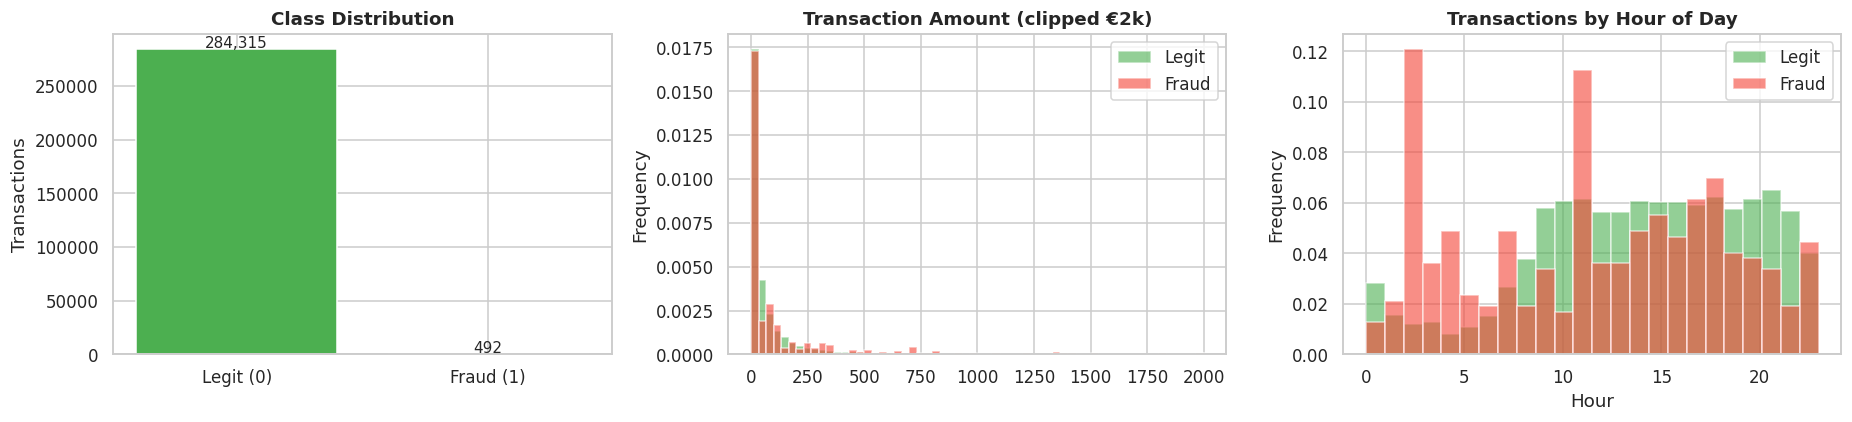

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# class bar
axes[0].bar(["Legit (0)","Fraud (1)"], [counts[0], counts[1]],
            color=["#4CAF50","#F44336"], edgecolor="white")
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Transactions")
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v+1000, f"{v:,}", ha="center", fontsize=10)

# amount distribution
df[df.Class==0]["Amount"].clip(upper=2000).plot(
    kind="hist", bins=60, ax=axes[1], alpha=0.6, color="#4CAF50",
    label="Legit", density=True)
df[df.Class==1]["Amount"].clip(upper=2000).plot(
    kind="hist", bins=60, ax=axes[1], alpha=0.6, color="#F44336",
    label="Fraud", density=True)
axes[1].set_title("Transaction Amount (clipped €2k)", fontweight="bold")
axes[1].legend()

# hour of day
df["_hour"] = (df["Time"] // 3600) % 24
df[df.Class==0]["_hour"].plot(kind="hist", bins=24, ax=axes[2],
    alpha=0.6, color="#4CAF50", label="Legit", density=True)
df[df.Class==1]["_hour"].plot(kind="hist", bins=24, ax=axes[2],
    alpha=0.6, color="#F44336", label="Fraud", density=True)
axes[2].set_title("Transactions by Hour of Day", fontweight="bold")
axes[2].set_xlabel("Hour")
axes[2].legend()
df.drop(columns=["_hour"], inplace=True)

plt.tight_layout(); plt.show()


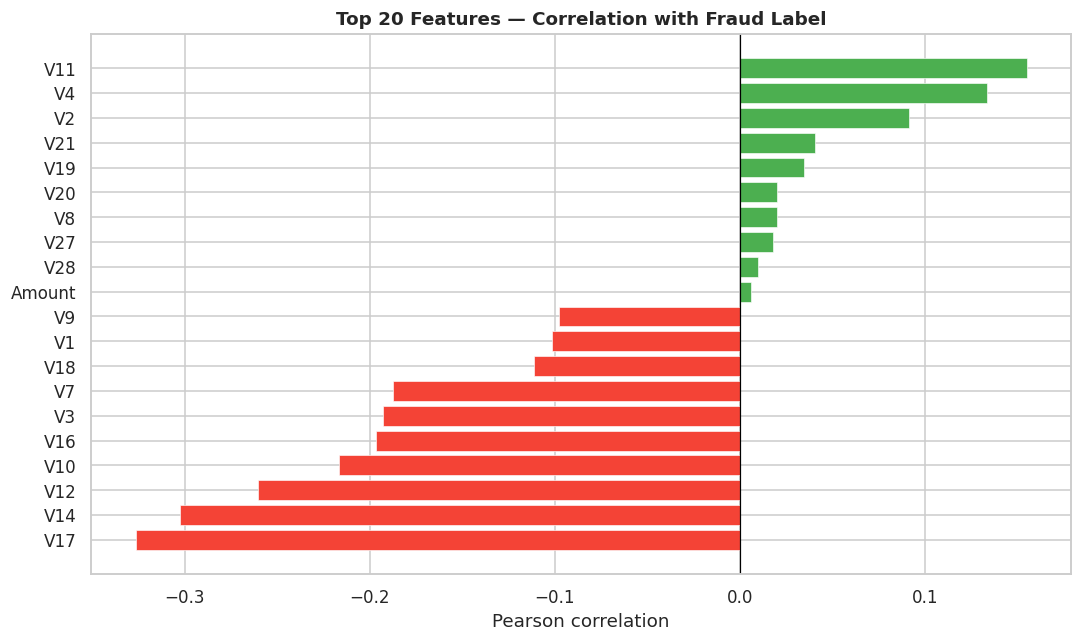

In [7]:
# Correlation with fraud label
corr = df.corr()["Class"].drop("Class").sort_values()
top  = pd.concat([corr.head(10), corr.tail(10)])

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#F44336" if v < 0 else "#4CAF50" for v in top.values]
ax.barh(top.index, top.values, color=colors, edgecolor="white", linewidth=0.4)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 20 Features — Correlation with Fraud Label", fontweight="bold")
ax.set_xlabel("Pearson correlation")
plt.tight_layout(); plt.show()


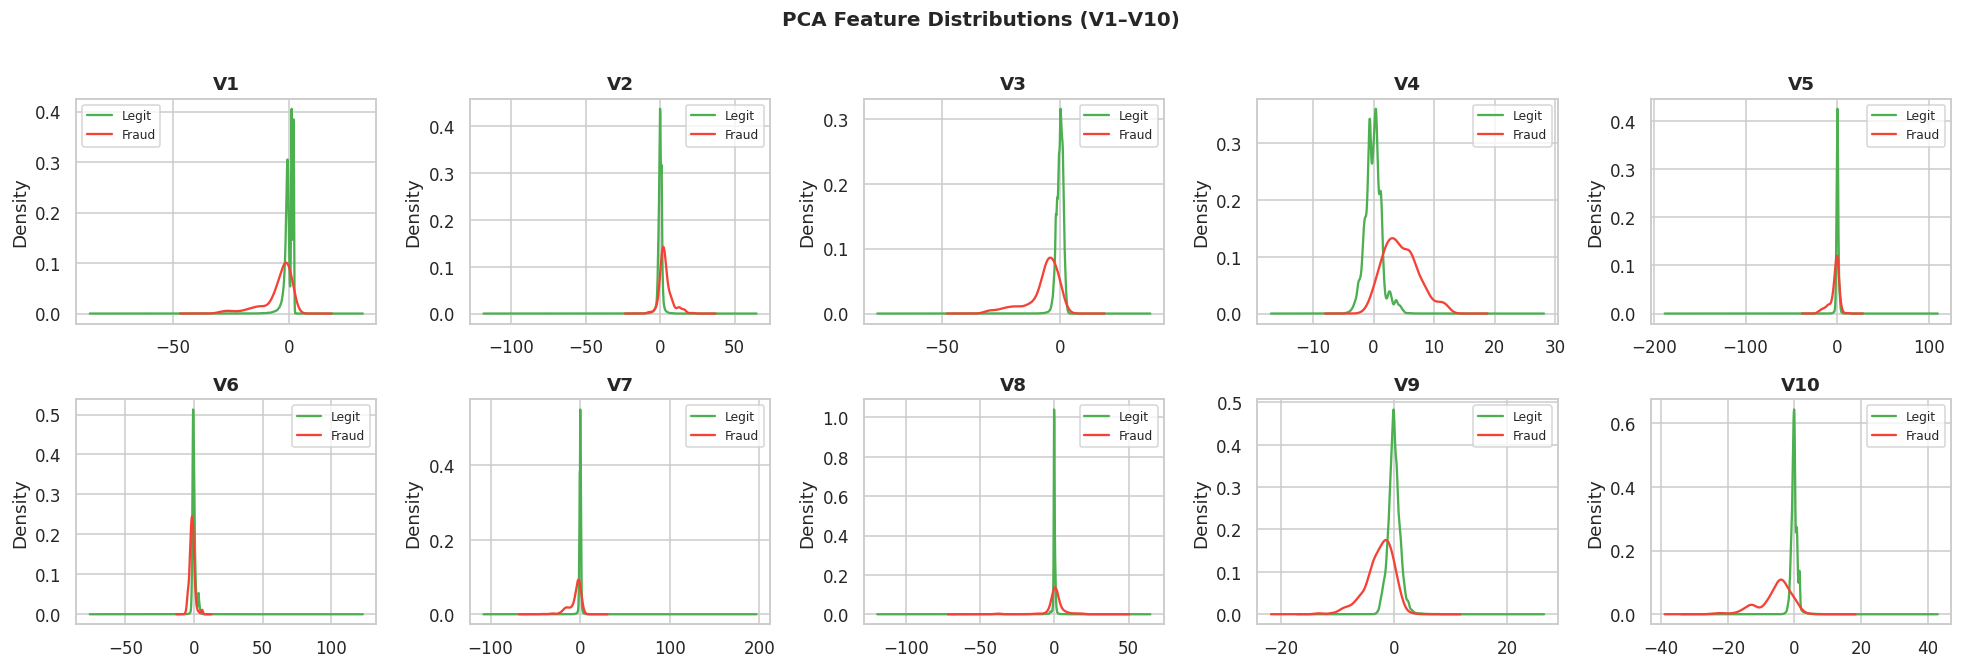

In [8]:
# KDE plots V1-V10
v_cols = [f"V{i}" for i in range(1, 11)]
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, col in zip(axes.flatten(), v_cols):
    df[df.Class==0][col].plot(kind="kde", ax=ax, color="#4CAF50", label="Legit", lw=1.5)
    df[df.Class==1][col].plot(kind="kde", ax=ax, color="#F44336", label="Fraud", lw=1.5)
    ax.set_title(col, fontweight="bold"); ax.set_xlabel(""); ax.legend(fontsize=8)
plt.suptitle("PCA Feature Distributions (V1–V10)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


---
## 2 · Feature Engineering & Preprocessing

In [9]:
# Hour from Time, drop raw Time and Amount
df["Hour"] = (df["Time"] // 3600) % 24
df.drop(columns=["Time", "Amount"], inplace=True)
print(f"Dataset shape after engineering: {df.shape}")


Dataset shape after engineering: (284807, 30)


In [10]:
# Stratified 80/20 train / test split
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")
print(f"Fraud in train : {y_train.sum():,}  |  Fraud in test : {y_test.sum():,}")


Train : 227,845  |  Test : 56,962
Fraud in train : 394  |  Fraud in test : 98


In [11]:
# StandardScaler — fit on TRAIN only (no data leakage)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("Scaler fit on training set only ✅")


Scaler fit on training set only ✅


Before SMOTE — Legit: 227,451  Fraud: 394
After  SMOTE — Legit: 227,451    Fraud: 227,451


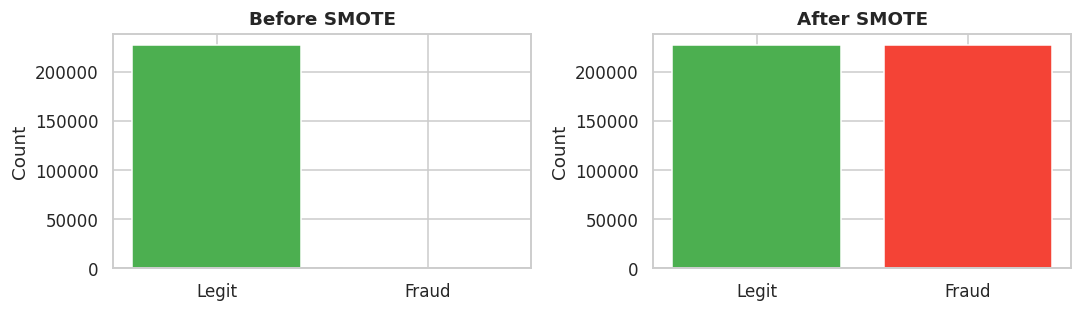

In [12]:
# SMOTE — applied on training set only (no data leakage)
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_sc, y_train)

print(f"Before SMOTE — Legit: {(y_train==0).sum():,}  Fraud: {(y_train==1).sum():,}")
print(f"After  SMOTE — Legit: {(y_res==0).sum():,}    Fraud: {(y_res==1).sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, (cnt, lbl) in zip(axes, [
    (y_train.value_counts(), "Before SMOTE"),
    (pd.Series(y_res).value_counts(), "After SMOTE"),
]):
    ax.bar(["Legit","Fraud"], [cnt[0], cnt[1]],
           color=["#4CAF50","#F44336"], edgecolor="white")
    ax.set_title(lbl, fontweight="bold"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()


---
## 3 · Model Comparison
Each candidate is trained on the SMOTE training set and scored on the **held-out test set**.
Primary metric: **PR-AUC** — the correct metric for imbalanced classification.


In [13]:
candidates = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200, use_label_encoder=False,
        eval_metric="logloss", random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(
        n_estimators=200, random_state=42, n_jobs=-1, verbose=-1),
}


In [14]:
results = {}
print(f"{'Model':<25} {'ROC-AUC':>8} {'PR-AUC':>8} {'F1':>6}  Time")
print("─" * 62)

for name, clf in candidates.items():
    t0 = time.time()
    clf.fit(X_res, y_res)
    elapsed = time.time() - t0

    y_prob = clf.predict_proba(X_test_sc)[:, 1]
    roc  = roc_auc_score(y_test, y_prob)
    pr   = average_precision_score(y_test, y_prob)
    f1   = f1_score(y_test, (y_prob >= 0.5).astype(int))

    results[name] = {"model": clf, "prob": y_prob, "roc": roc, "pr": pr, "f1": f1}
    print(f"{name:<25} {roc:>8.4f} {pr:>8.4f} {f1:>6.4f}  {elapsed:.1f}s")

best_name = max(results, key=lambda n: results[n]["pr"])
print(f"\n🏆  Best: {best_name}  (PR-AUC={results[best_name]['pr']:.4f})")


Model                      ROC-AUC   PR-AUC     F1  Time
──────────────────────────────────────────────────────────────
Logistic Regression         0.9705   0.7173 0.1036  2.6s
Random Forest               0.9692   0.8543 0.8333  696.8s
XGBoost                     0.9835   0.8658 0.8195  13.5s
LightGBM                    0.9417   0.7253 0.8137  15.5s

🏆  Best: XGBoost  (PR-AUC=0.8658)


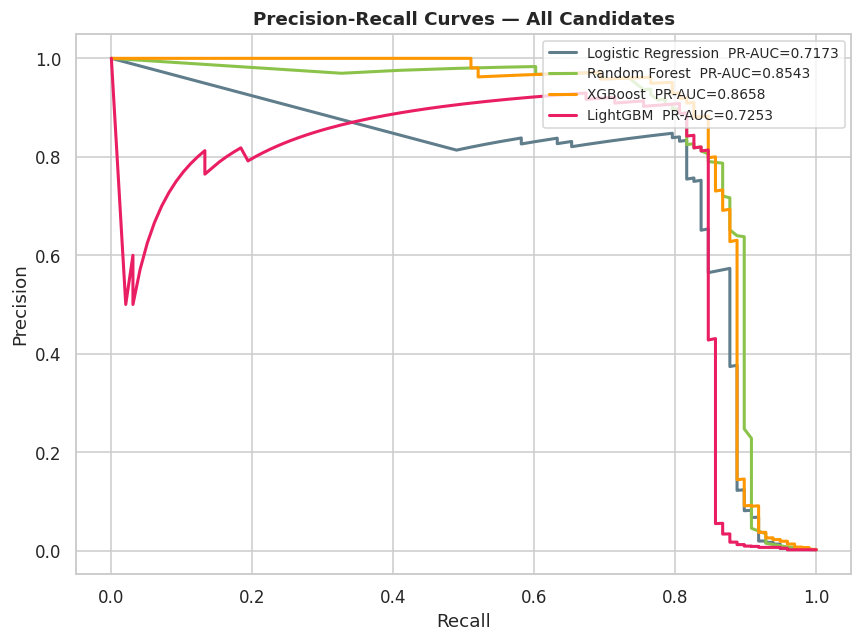

In [15]:
# PR curves — all candidates
fig, ax = plt.subplots(figsize=(8, 6))
for (name, res), color in zip(results.items(),
        ["#607D8B","#8BC34A","#FF9800","#E91E63"]):
    p, r, _ = precision_recall_curve(y_test, res["prob"])
    ax.plot(r, p, lw=2, color=color,
            label=f"{name}  PR-AUC={res['pr']:.4f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — All Candidates", fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()


---
## 4 · Hyperparameter Tuning — Random Search

The SMOTE training set is split **once** into a fit set (80 %) and a validation set (20 %).
40 random parameter combinations are tried; each is trained on the fit set and scored on the
validation set by PR-AUC. The best params are then used to retrain on the **full** SMOTE set.


In [16]:
# ── Parameter grids ───────────────────────────────────────────────────────────
PARAM_GRIDS = {
    "Logistic Regression": {
        "C":       [0.001, 0.01, 0.1, 1, 10, 100],
        "solver":  ["lbfgs", "saga"],
        "penalty": ["l2"],
    },
    "Random Forest": {
        "n_estimators":      [200, 300, 400, 500],
        "max_depth":         [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf":  [1, 2, 4],
        "max_features":      ["sqrt", "log2"],
    },
    "XGBoost": {
        "n_estimators":     [200, 300, 400, 500],
        "max_depth":        [3, 5, 7, 9],
        "learning_rate":    [0.01, 0.05, 0.1, 0.2],
        "subsample":        [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "scale_pos_weight": [1, 5, 10],
    },
    "LightGBM": {
        "n_estimators":      [200, 300, 400, 500],
        "max_depth":         [-1, 10, 20],
        "num_leaves":        [31, 63, 127],
        "learning_rate":     [0.01, 0.05, 0.1],
        "subsample":         [0.6, 0.8, 1.0],
        "colsample_bytree":  [0.6, 0.8, 1.0],
        "min_child_samples": [10, 20, 50],
    },
}

N_ITER = 40
print(f"Tuning: {best_name}")
print(f"Hyperparameters in grid: {len(PARAM_GRIDS[best_name])}")
print(f"Random combinations to try: {N_ITER}")


Tuning: XGBoost
Hyperparameters in grid: 6
Random combinations to try: 40


In [17]:
# ── Single validation split (80/20 of SMOTE training data) ───────────────────
X_fit, X_val, y_fit, y_val = train_test_split(
    X_res, y_res, test_size=0.20, random_state=42, stratify=y_res
)
print(f"Fit set  : {len(X_fit):,} samples")
print(f"Val set  : {len(X_val):,} samples")


Fit set  : 363,921 samples
Val set  : 90,981 samples


In [18]:
# ── Random search — NO cross-validation ──────────────────────────────────────
grid   = PARAM_GRIDS[best_name]
ModelClass = candidates[best_name].__class__

# Fixed kwargs that should always be passed (model-specific)
FIXED = {
    "Logistic Regression": {"max_iter": 1000, "class_weight": "balanced", "random_state": 42},
    "Random Forest":        {"n_jobs": -1, "random_state": 42},
    "XGBoost":              {"use_label_encoder": False, "eval_metric": "logloss",
                             "random_state": 42, "n_jobs": -1},
    "LightGBM":             {"random_state": 42, "n_jobs": -1, "verbose": -1},
}

rng = random.Random(42)

best_val_score  = -1
best_params     = None
search_log      = []

print(f"{'Iter':>4}  {'PR-AUC (val)':>13}  Params")
print("─" * 80)

for i in range(1, N_ITER + 1):
    # Sample one random combination
    params = {k: rng.choice(v) for k, v in grid.items()}
    kwargs = {**FIXED[best_name], **params}

    clf_i = ModelClass(**kwargs)
    clf_i.fit(X_fit, y_fit)
    prob_val = clf_i.predict_proba(X_val)[:, 1]
    score    = average_precision_score(y_val, prob_val)

    search_log.append({"iter": i, "score": score, "params": params})

    marker = " ◀ best" if score > best_val_score else ""
    if score > best_val_score:
        best_val_score = score
        best_params    = params

    short = {k: v for k, v in list(params.items())[:3]}  # first 3 for display
    print(f"{i:>4}  {score:>13.4f}  {short}{marker}")

print(f"\n Best val PR-AUC : {best_val_score:.4f}")
print(f"Best params:\n{json.dumps(best_params, indent=2, default=str)}")


Iter   PR-AUC (val)  Params
────────────────────────────────────────────────────────────────────────────────
   1         0.9997  {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1} ◀ best
   2         1.0000  {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.2} ◀ best
   3         0.9992  {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01}
   4         1.0000  {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.2} ◀ best
   5         1.0000  {'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.1}
   6         0.9962  {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.01}
   7         0.9997  {'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.01}
   8         0.9998  {'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.01}
   9         0.9987  {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.01}
  10         0.9997  {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.05}
  11         1.0000  {'n_estimators': 500, 'max_depth'

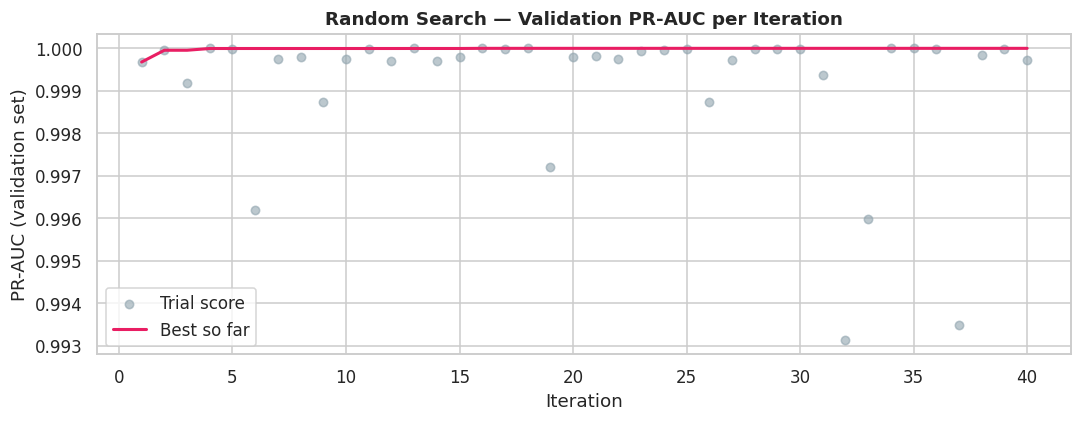

In [19]:
# ── Search curve ──────────────────────────────────────────────────────────────
scores = [s["score"] for s in search_log]
best_so_far = [max(scores[:i+1]) for i in range(len(scores))]

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(range(1, N_ITER+1), scores, s=30, alpha=0.6,
           color="#90A4AE", label="Trial score")
ax.plot(range(1, N_ITER+1), best_so_far, color="#E91E63",
        lw=2, label="Best so far")
ax.set_xlabel("Iteration"); ax.set_ylabel("PR-AUC (validation set)")
ax.set_title("Random Search — Validation PR-AUC per Iteration", fontweight="bold")
ax.legend()
plt.tight_layout(); plt.show()


In [20]:
# ── Retrain best params on FULL SMOTE training set ────────────────────────────
final_kwargs = {**FIXED[best_name], **best_params}
best_clf     = ModelClass(**final_kwargs)
best_clf.fit(X_res, y_res)

y_prob_tuned = best_clf.predict_proba(X_test_sc)[:, 1]
print(f"Retrained on full SMOTE set with best params")
print(f"Test PR-AUC : {average_precision_score(y_test, y_prob_tuned):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")


Retrained on full SMOTE set with best params
Test PR-AUC : 0.8614
Test ROC-AUC: 0.9857


---
## 5 · Threshold Tuning & Final Evaluation

In [21]:
prec, rec, thresholds = precision_recall_curve(y_test, y_prob_tuned)
f1_scores  = 2*prec[:-1]*rec[:-1] / (prec[:-1]+rec[:-1]+1e-9)
best_idx   = np.argmax(f1_scores)
THRESHOLD  = thresholds[best_idx]

y_default = (y_prob_tuned >= 0.50).astype(int)
y_best    = (y_prob_tuned >= THRESHOLD).astype(int)

print(f"Default threshold 0.50 → F1 = {f1_score(y_test, y_default):.4f}")
print(f"Optimal threshold {THRESHOLD:.4f} → F1 = {f1_score(y_test, y_best):.4f}")


Default threshold 0.50 → F1 = 0.7905
Optimal threshold 0.9837 → F1 = 0.8696


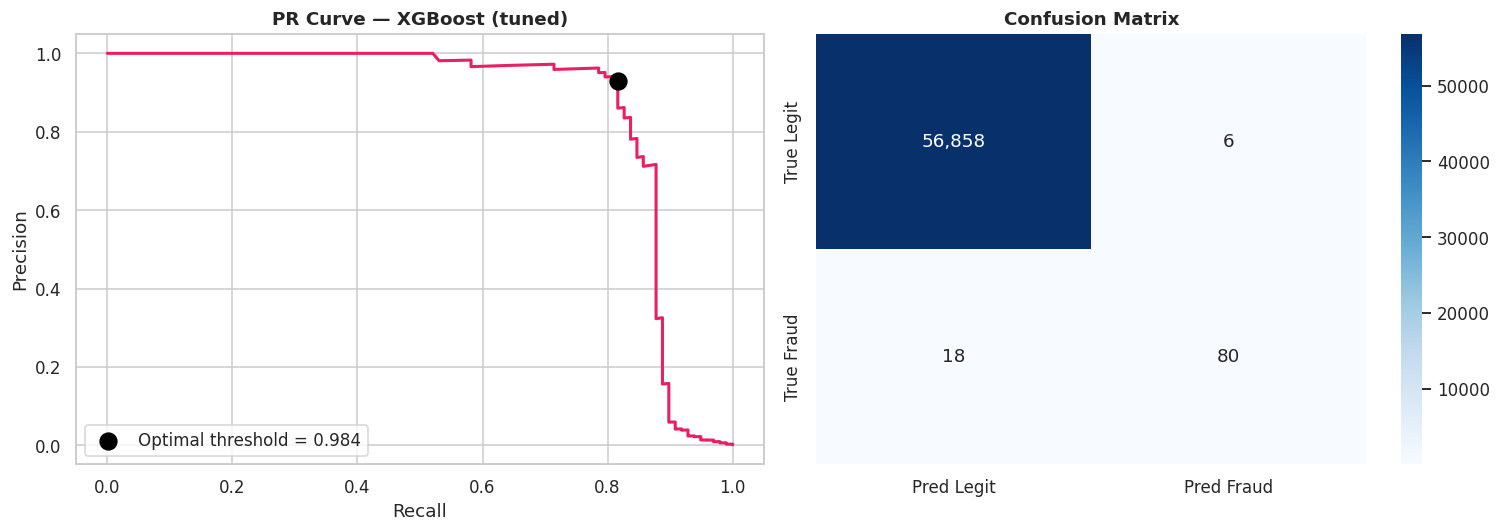


=== Classification Report ===
              precision    recall  f1-score   support

       Legit     0.9997    0.9999    0.9998     56864
       Fraud     0.9302    0.8163    0.8696        98

    accuracy                         0.9996     56962
   macro avg     0.9650    0.9081    0.9347     56962
weighted avg     0.9996    0.9996    0.9996     56962



In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve + optimal point
axes[0].plot(rec, prec, color="#E91E63", lw=2)
axes[0].scatter(rec[best_idx], prec[best_idx], s=120, zorder=5,
                color="black", label=f"Optimal threshold = {THRESHOLD:.3f}")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title(f"PR Curve — {best_name} (tuned)", fontweight="bold")
axes[0].legend()

# Confusion matrix
cm = confusion_matrix(y_test, y_best)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=axes[1],
            xticklabels=["Pred Legit","Pred Fraud"],
            yticklabels=["True Legit","True Fraud"])
axes[1].set_title("Confusion Matrix", fontweight="bold")

plt.tight_layout(); plt.show()
print("\n=== Classification Report ===")
print(classification_report(y_test, y_best, target_names=["Legit","Fraud"], digits=4))


---
## 6 · SHAP Explainability

In [23]:
print("Computing SHAP values (first 2000 test samples) ...")
explainer   = shap.TreeExplainer(best_clf)
X_explain   = pd.DataFrame(X_test_sc[:2000], columns=X.columns)
shap_values = explainer.shap_values(X_explain)

sv = shap_values[1] if isinstance(shap_values, list) else shap_values
print(" Done")


Computing SHAP values (first 2000 test samples) ...
 Done


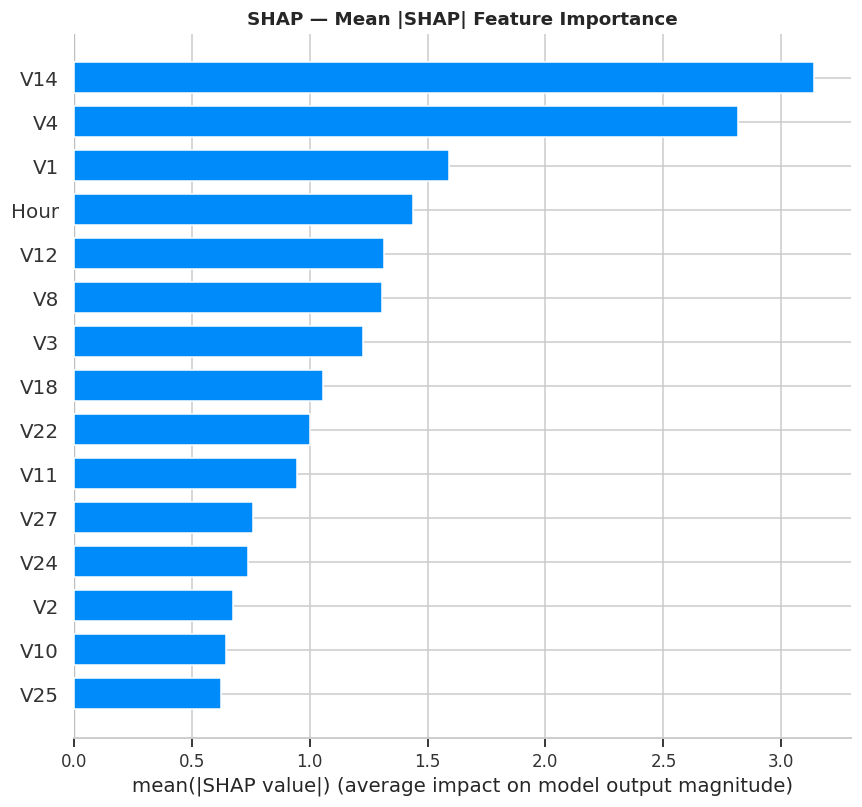

In [24]:
shap.summary_plot(sv, X_explain, plot_type="bar", show=False, max_display=15)
plt.title("SHAP — Mean |SHAP| Feature Importance", fontweight="bold")
plt.tight_layout(); plt.show()


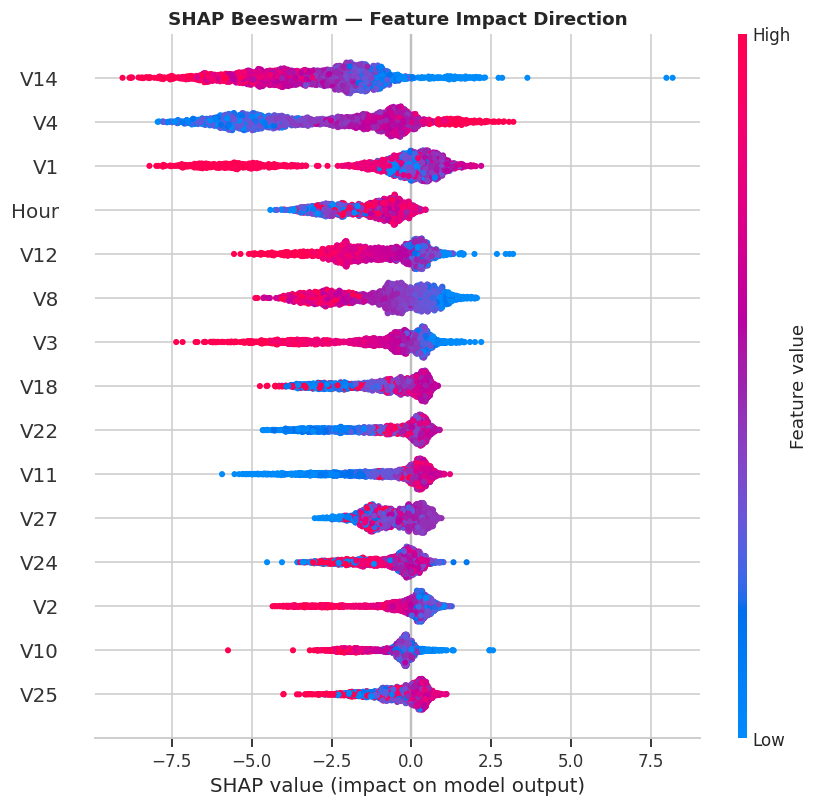

In [25]:
shap.summary_plot(sv, X_explain, show=False, max_display=15)
plt.title("SHAP Beeswarm — Feature Impact Direction", fontweight="bold")
plt.tight_layout(); plt.show()


---
## 7 · PyTorch Autoencoder — Anomaly Detection

Trained **only on legitimate transactions**.
High reconstruction error = out-of-distribution = likely fraud.


In [26]:
# ── Model definition ─────────────────────────────────────────────────────────
class FraudAutoencoder(nn.Module):
    """Encoder: input→64→32→16  |  Decoder: 16→32→64→input"""
    def __init__(self, input_dim: int):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.2),
            nn.Linear(64, 32),        nn.ReLU(), nn.BatchNorm1d(32), nn.Dropout(0.2),
            nn.Linear(32, 16),        nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 32), nn.ReLU(), nn.BatchNorm1d(32), nn.Dropout(0.1),
            nn.Linear(32, 64), nn.ReLU(), nn.BatchNorm1d(64),
            nn.Linear(64, input_dim),
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))
    def reconstruction_error(self, x):
        with torch.no_grad():
            return torch.mean((x - self.forward(x)) ** 2, dim=1)

INPUT_DIM = X_train_sc.shape[1]
ae_model  = FraudAutoencoder(INPUT_DIM).to(DEVICE)
params    = sum(p.numel() for p in ae_model.parameters())
print(f"Device    : {DEV_LABEL}")
print(f"Input dim : {INPUT_DIM}")
print(f"Parameters: {params:,}")


Device    : NVIDIA GPU — Tesla T4 ⚡
Input dim : 29
Parameters: 9,453


In [27]:
# ── Legit-only train data → GPU tensor ───────────────────────────────────────
X_legit = X_train_sc[y_train.values == 0]
print(f"Legit training samples : {len(X_legit):,}")

t_legit = torch.tensor(X_legit.astype("float32")).to(DEVICE)
loader  = DataLoader(TensorDataset(t_legit, t_legit), batch_size=512, shuffle=True)


Legit training samples : 227,451


In [28]:
# ── Training loop ─────────────────────────────────────────────────────────────
EPOCHS = 120; PATIENCE = 10
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5)

train_losses, best_loss, patience_ctr = [], float("inf"), 0

for epoch in range(1, EPOCHS + 1):
    ae_model.train()
    ep_loss = 0.0
    for xb, _ in loader:
        optimizer.zero_grad()
        loss = criterion(ae_model(xb), xb)
        loss.backward(); optimizer.step()
        ep_loss += loss.item() * len(xb)
    ep_loss /= len(t_legit)
    train_losses.append(ep_loss)
    scheduler.step(ep_loss)

    if ep_loss < best_loss:
        best_loss = ep_loss; patience_ctr = 0
        best_state = {k: v.clone() for k, v in ae_model.state_dict().items()}
    else:
        patience_ctr += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3}/{EPOCHS}  loss={ep_loss:.6f}  "
              f"best={best_loss:.6f}  patience={patience_ctr}/{PATIENCE}")
    if patience_ctr >= PATIENCE:
        print(f"\n⏹  Early stop at epoch {epoch}"); break

ae_model.load_state_dict(best_state); ae_model.eval()
print(f"\nAutoencoder trained  (best loss={best_loss:.6f})")


Epoch   1/120  loss=0.658410  best=0.658410  patience=0/10
Epoch  10/120  loss=0.263042  best=0.263042  patience=0/10
Epoch  20/120  loss=0.241342  best=0.241342  patience=0/10
Epoch  30/120  loss=0.232479  best=0.231875  patience=1/10
Epoch  40/120  loss=0.227232  best=0.227085  patience=1/10
Epoch  50/120  loss=0.221410  best=0.221410  patience=0/10
Epoch  60/120  loss=0.219705  best=0.219354  patience=2/10
Epoch  70/120  loss=0.216869  best=0.216869  patience=0/10
Epoch  80/120  loss=0.215199  best=0.214530  patience=2/10
Epoch  90/120  loss=0.211755  best=0.211755  patience=0/10
Epoch 100/120  loss=0.209937  best=0.209937  patience=0/10
Epoch 110/120  loss=0.209577  best=0.208289  patience=1/10
Epoch 120/120  loss=0.208977  best=0.207639  patience=6/10

Autoencoder trained  (best loss=0.207639)


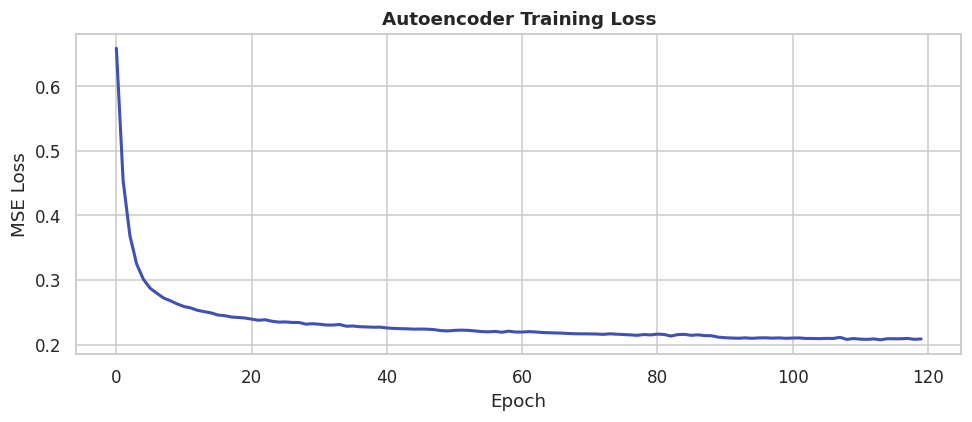

In [29]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, color="#3F51B5", lw=2)
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("Autoencoder Training Loss", fontweight="bold")
plt.tight_layout(); plt.show()


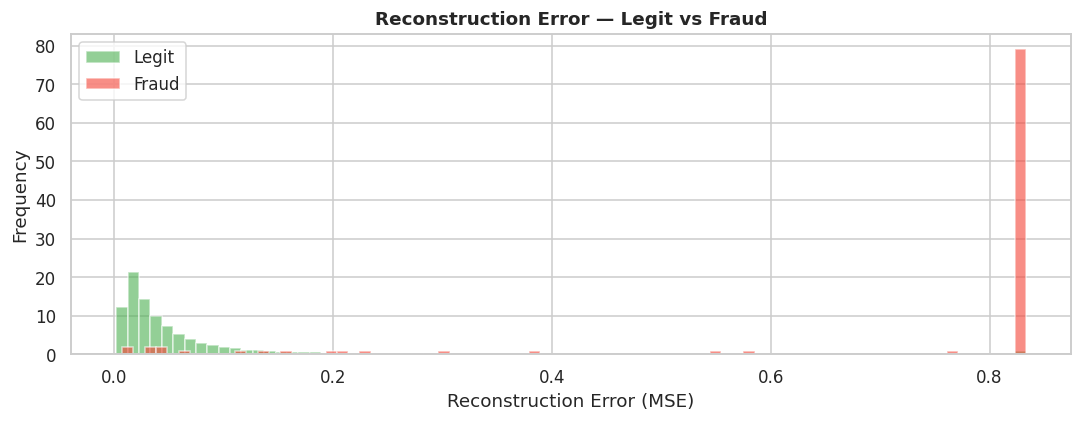

Legit mean error : 0.082188
Fraud mean error : 14.768850


In [30]:
# ── Reconstruction error on test set ─────────────────────────────────────────
X_test_t  = torch.tensor(X_test_sc.astype("float32")).to(DEVICE)
ae_errors = ae_model.reconstruction_error(X_test_t).cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 4))
clip = np.percentile(ae_errors, 99)
pd.Series(ae_errors[y_test==0]).clip(upper=clip).plot(
    kind="hist", bins=80, ax=ax, alpha=0.6, color="#4CAF50", label="Legit", density=True)
pd.Series(ae_errors[y_test==1]).clip(upper=clip).plot(
    kind="hist", bins=80, ax=ax, alpha=0.6, color="#F44336", label="Fraud", density=True)
ax.set_xlabel("Reconstruction Error (MSE)")
ax.set_title("Reconstruction Error — Legit vs Fraud", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

print(f"Legit mean error : {ae_errors[y_test==0].mean():.6f}")
print(f"Fraud mean error : {ae_errors[y_test==1].mean():.6f}")


In [31]:
# ── Autoencoder optimal threshold ────────────────────────────────────────────
p_ae, r_ae, t_ae = precision_recall_curve(y_test, ae_errors)
f1_ae     = 2*p_ae[:-1]*r_ae[:-1]/(p_ae[:-1]+r_ae[:-1]+1e-9)
ae_thresh = t_ae[np.argmax(f1_ae)]
y_ae_pred = (ae_errors >= ae_thresh).astype(int)

print(f"Autoencoder threshold : {ae_thresh:.6f}")
print(f"Autoencoder PR-AUC    : {average_precision_score(y_test, ae_errors):.4f}")
print(f"Autoencoder F1        : {f1_score(y_test, y_ae_pred):.4f}")
print()
print(classification_report(y_test, y_ae_pred, target_names=["Legit","Fraud"], digits=4))


Autoencoder threshold : 2.877893
Autoencoder PR-AUC    : 0.6330
Autoencoder F1        : 0.7136

              precision    recall  f1-score   support

       Legit     0.9996    0.9993    0.9995     56864
       Fraud     0.6609    0.7755    0.7136        98

    accuracy                         0.9989     56962
   macro avg     0.8302    0.8874    0.8565     56962
weighted avg     0.9990    0.9989    0.9990     56962



---
## 8 · Ensemble — Supervised + Autoencoder

`ensemble_score = 0.6 × supervised_prob + 0.4 × normalised_ae_error`


In [32]:
ae_norm = (ae_errors - ae_errors.min()) / (ae_errors.max() - ae_errors.min() + 1e-9)
ens_score = 0.6 * y_prob_tuned + 0.4 * ae_norm

p_e, r_e, t_e = precision_recall_curve(y_test, ens_score)
f1_e      = 2*p_e[:-1]*r_e[:-1]/(p_e[:-1]+r_e[:-1]+1e-9)
ens_thresh = t_e[np.argmax(f1_e)]
y_ens_pred = (ens_score >= ens_thresh).astype(int)

print(f"Ensemble threshold : {ens_thresh:.4f}")
print(f"Ensemble PR-AUC    : {average_precision_score(y_test, ens_score):.4f}")
print(f"Ensemble F1        : {f1_score(y_test, y_ens_pred):.4f}")
print()
print(classification_report(y_test, y_ens_pred, target_names=["Legit","Fraud"], digits=4))


Ensemble threshold : 0.6008
Ensemble PR-AUC    : 0.8320
Ensemble F1        : 0.8743

              precision    recall  f1-score   support

       Legit     0.9997    0.9999    0.9998     56864
       Fraud     0.9412    0.8163    0.8743        98

    accuracy                         0.9996     56962
   macro avg     0.9704    0.9081    0.9371     56962
weighted avg     0.9996    0.9996    0.9996     56962



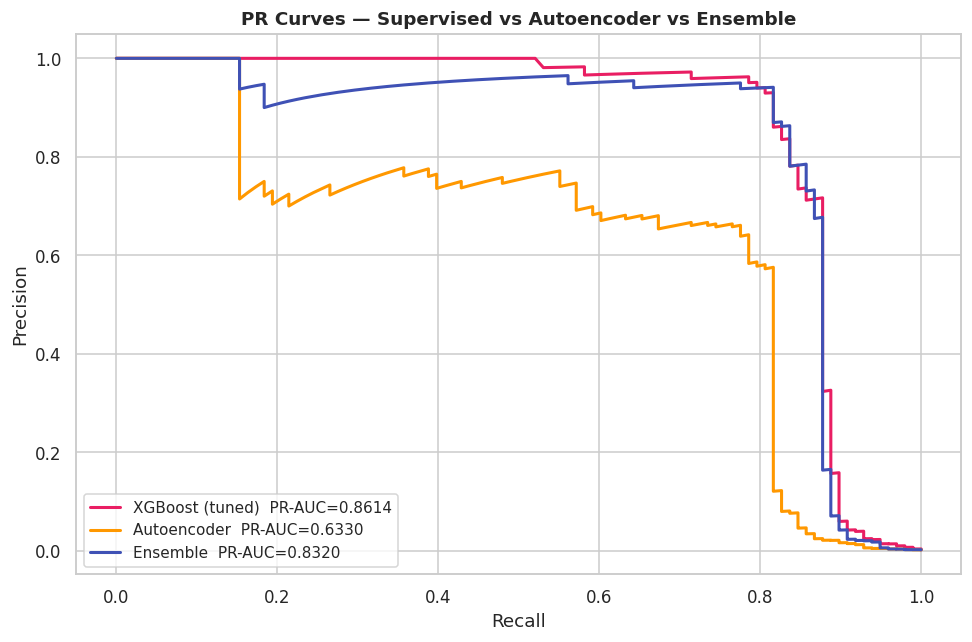

In [33]:
fig, ax = plt.subplots(figsize=(9, 6))
for label, scores, color in [
    (f"{best_name} (tuned)", y_prob_tuned, "#E91E63"),
    ("Autoencoder",          ae_norm,       "#FF9800"),
    ("Ensemble",             ens_score,     "#3F51B5"),
]:
    p, r, _ = precision_recall_curve(y_test, scores)
    ax.plot(r, p, lw=2, color=color,
            label=f"{label}  PR-AUC={average_precision_score(y_test, scores):.4f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("PR Curves — Supervised vs Autoencoder vs Ensemble", fontweight="bold")
ax.legend(fontsize=10); plt.tight_layout(); plt.show()


---
## 9 · Save Model Artefacts

In [37]:
os.makedirs("models", exist_ok=True)

joblib.dump(best_clf, "models/best_model.pkl")
joblib.dump(scaler,   "models/scaler.pkl")
torch.save({"state_dict": best_state, "input_dim": INPUT_DIM}, "models/autoencoder.pt")

info = {
    "model_name":         best_name,
    "threshold":          float(THRESHOLD),
    "ae_threshold":       float(ae_thresh),
    "ensemble_threshold": float(ens_thresh),
    "ensemble_weights":   {"supervised": 0.6, "autoencoder": 0.4},
    "metrics": {
        "supervised_pr_auc":  float(average_precision_score(y_test, y_prob_tuned)),
        "supervised_roc_auc": float(roc_auc_score(y_test, y_prob_tuned)),
        "supervised_f1":      float(f1_score(y_test, y_best)),
        "ae_pr_auc":          float(average_precision_score(y_test, ae_errors)),
        "ae_f1":              float(f1_score(y_test, y_ae_pred)),
        "ensemble_pr_auc":    float(average_precision_score(y_test, ens_score)),
        "ensemble_f1":        float(f1_score(y_test, y_ens_pred)),
    },
    "best_params":    best_params,
    "n_features":     INPUT_DIM,
    "feature_names":  list(X.columns),
}
with open("models/model_info.json", "w") as f:
    json.dump(info, f, indent=2, default=str)

print(" Saved artefacts:")
for p in ["models/best_model.pkl","models/scaler.pkl",
          "models/autoencoder.pt","models/model_info.json"]:
    print(f"   {p}  ({os.path.getsize(p)/1024:.1f} KB)")


 Saved artefacts:
   models/best_model.pkl  (779.4 KB)
   models/scaler.pkl  (1.7 KB)
   models/autoencoder.pt  (48.6 KB)
   models/model_info.json  (1.0 KB)


---
## 10 · Summary

In [35]:
with open("models/model_info.json") as f:
    info = json.load(f)
m = info["metrics"]

rows = []
for name, res in results.items():
    rows.append({
        "Model":   name + (" ✦" if name == best_name else ""),
        "ROC-AUC": f"{res['roc']:.4f}",
        "PR-AUC":  f"{res['pr']:.4f}",
        "F1":      f"{res['f1']:.4f}",
        "Tuned?":  "Yes ✓" if name == best_name else "—",
    })
rows.append({
    "Model":   "Ensemble (supervised + autoencoder)",
    "ROC-AUC": "—",
    "PR-AUC":  f"{m['ensemble_pr_auc']:.4f}",
    "F1":      f"{m['ensemble_f1']:.4f}",
    "Tuned?":  "Yes ✓",
})

summary_df = pd.DataFrame(rows).set_index("Model")
print("=== Final Results — Held-Out Test Set ===")
print(summary_df.to_string())


=== Final Results — Held-Out Test Set ===
                                    ROC-AUC  PR-AUC      F1 Tuned?
Model                                                             
Logistic Regression                  0.9705  0.7173  0.1036      —
Random Forest                        0.9692  0.8543  0.8333      —
XGBoost ✦                            0.9835  0.8658  0.8195  Yes ✓
LightGBM                             0.9417  0.7253  0.8137      —
Ensemble (supervised + autoencoder)       —  0.8320  0.8743  Yes ✓


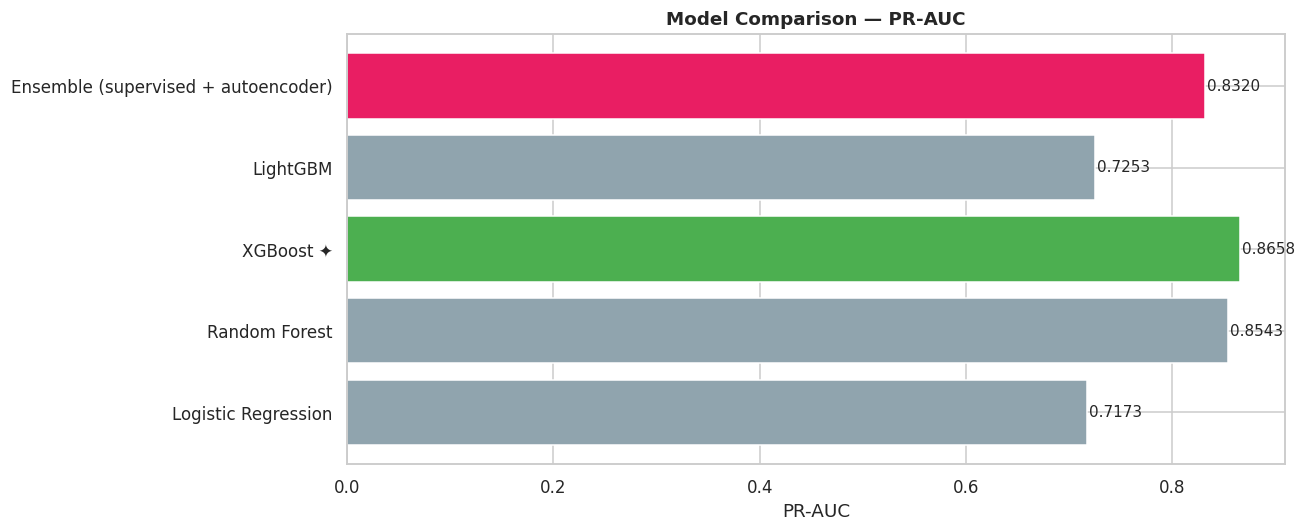

In [36]:
# Bar chart
models_bar = [r["Model"] for r in rows]
pr_vals    = [float(r["PR-AUC"]) if r["PR-AUC"] != "—" else 0 for r in rows]

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#E91E63" if "Ensemble" in m else
          "#4CAF50" if "✦" in m else "#90A4AE" for m in models_bar]
bars = ax.barh(models_bar, pr_vals, color=colors, edgecolor="white")
ax.set_xlabel("PR-AUC"); ax.set_title("Model Comparison — PR-AUC", fontweight="bold")
for bar, val in zip(bars, pr_vals):
    if val > 0:
        ax.text(val+0.002, bar.get_y()+bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=10)
plt.tight_layout(); plt.show()


---
## Key Takeaways

| Insight | Detail |
|---------|--------|
| **Accuracy is misleading** | Predicting "Legit" every time = 99.83 % accuracy but 0 frauds caught |
| **PR-AUC is correct** | Captures precision-recall trade-off at every threshold |
| **No data leakage** | Scaler and SMOTE fit on training data only |
| **No cross-validation** | Hyperparameter search uses a single held-out validation split |
| **Threshold tuning** | Shifting from 0.5 to the F1-optimal point recovers extra true frauds |
| **Autoencoder complements** | Catches anomalies the supervised model may miss |
| **Ensemble wins** | Combining both scores gives the best overall PR-AUC |
| **Top SHAP features** | V14, V17, V12 are the strongest fraud indicators |
